# Plot the global time series for a given model and variable

In [1]:
print('Loading packages...')
import sys
sys.path.append('../00_modules/.')
from import_packages import PackageGetter
globals().update(PackageGetter.import_standard_packages_for_analysis_and_plotting())
globals().update(PackageGetter.import_custom_packages())

Loading packages...


## Set parameters

In [2]:
#stat = 'integral'#'integral'#'mean'
freq_input = 'monthly'#, 'yearly', 'daily'] #freq_output = 'monthly'#, 'yearly', 'daily', 'climatology', None]
varias = ['fgco2','intpp','tas','tos','npp','nbp'] # 'tas','tos',
models = ['IPSL-CM6-ESMCO2','GFDL-ESM2M','NorESM2-LM']#,
runs = pruns.get_run_list('tipmip_tier1')#[1:]

model_dict = pmods.get_model_dict('all')
run_dict = pruns.get_run_dict()


## Convert time series

In [3]:
def convert_units(varia,stat,da):
    if varia == 'fgco2' and stat == 'integral' and da.units == 'kg m-2 s-1 x m2':
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'nbp' and stat == 'integral' and da.units == 'kg m-2 s-1 x m2':
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'intpp' and stat == 'integral' and da.units == 'mol m-2 s-1 x m2':
        converter = 12 * 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    elif varia == 'npp' and stat == 'integral' and da.units == 'kg m-2 s-1 x m2':
        converter = 24 * 3600 * 365 / 1000 / 1000 / 1000 / 1000
        da_conv = da*converter
        da_conv.attrs["units"] = r'PgC yr-1'
    else:
        da_conv = da
    return da_conv

def get_stat(varia,default=True):
    if default == True:
        if varia in ['tas','tos']:
            stat = 'mean'
        elif varia in ['fgco2','intpp','nbp','npp']:
            stat = 'integral'
    else:
        stat = 'mean'
    return stat

## Load and plot

Nothing to plot for fgco2, IPSL-CM6-ESMCO2, r1i2p3f1, esm-piControl, monthly, global integral.


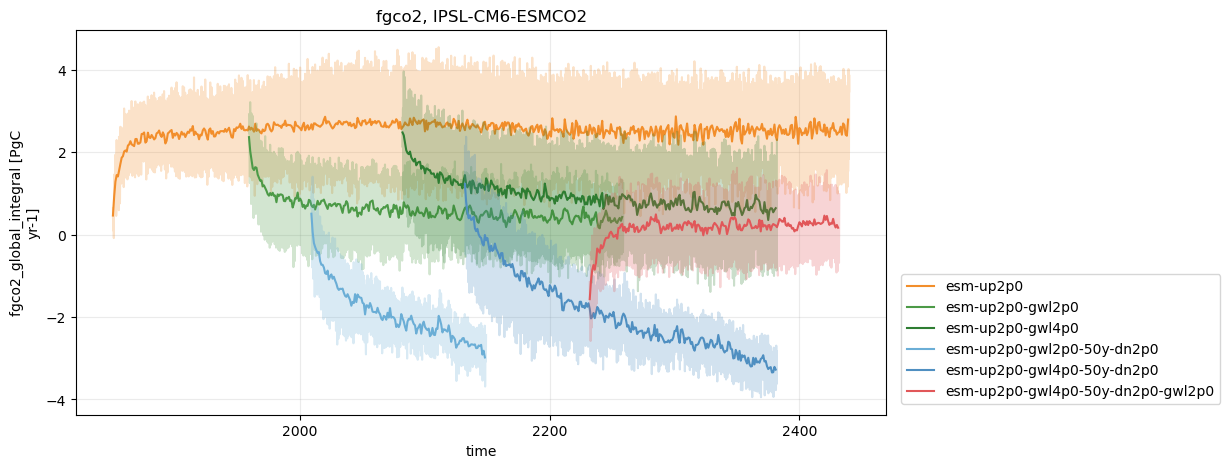

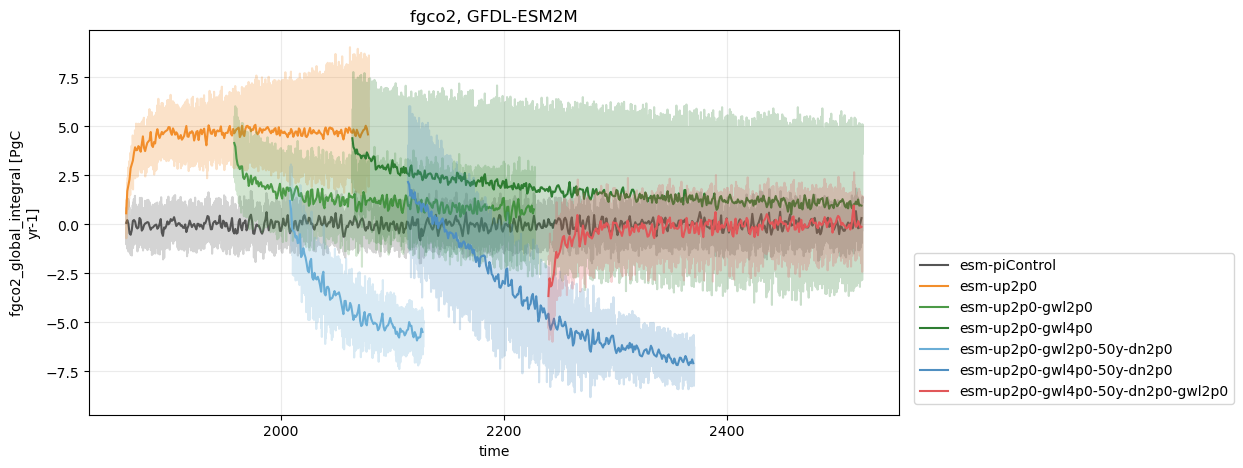

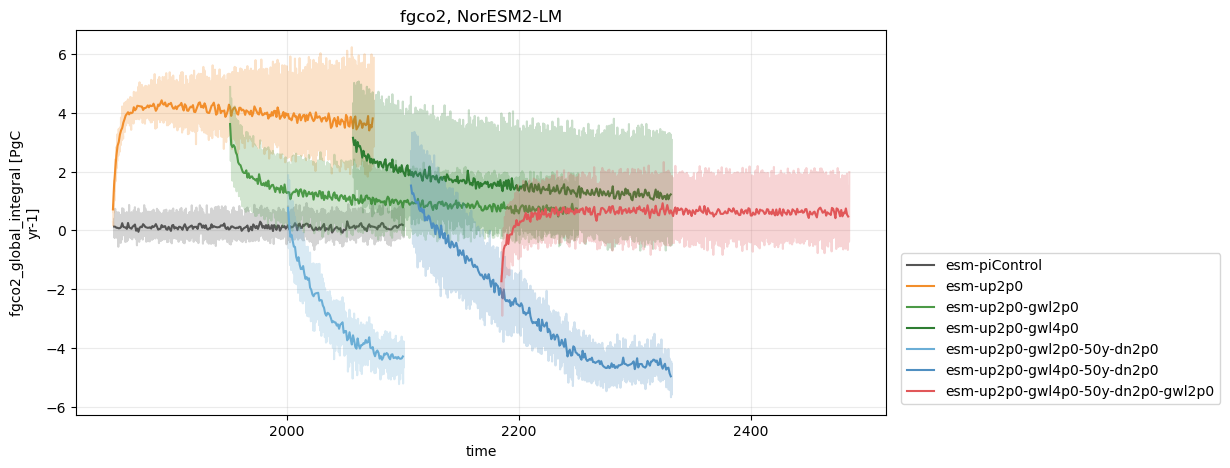

Nothing to plot for intpp, IPSL-CM6-ESMCO2, r1i2p3f1, esm-piControl, monthly, global integral.


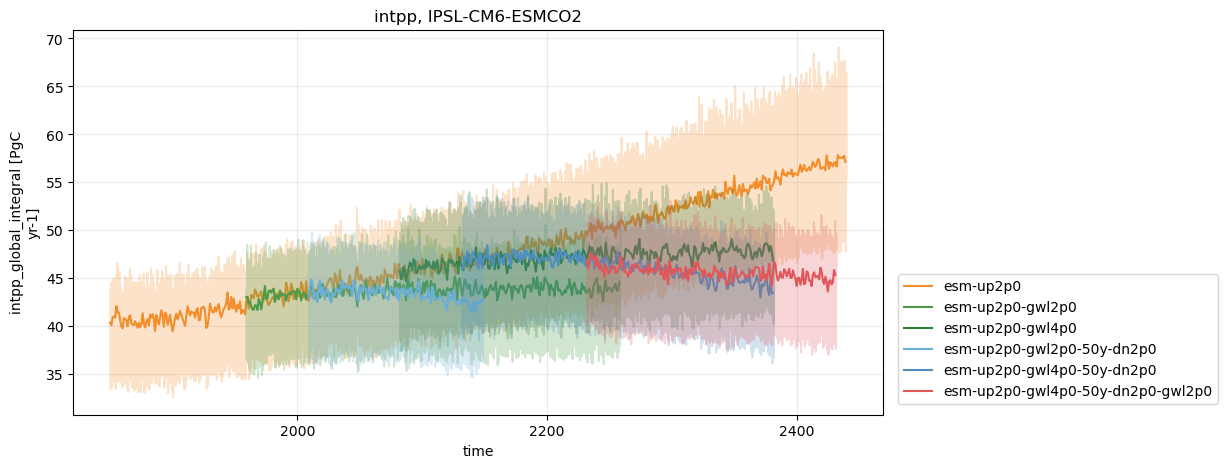

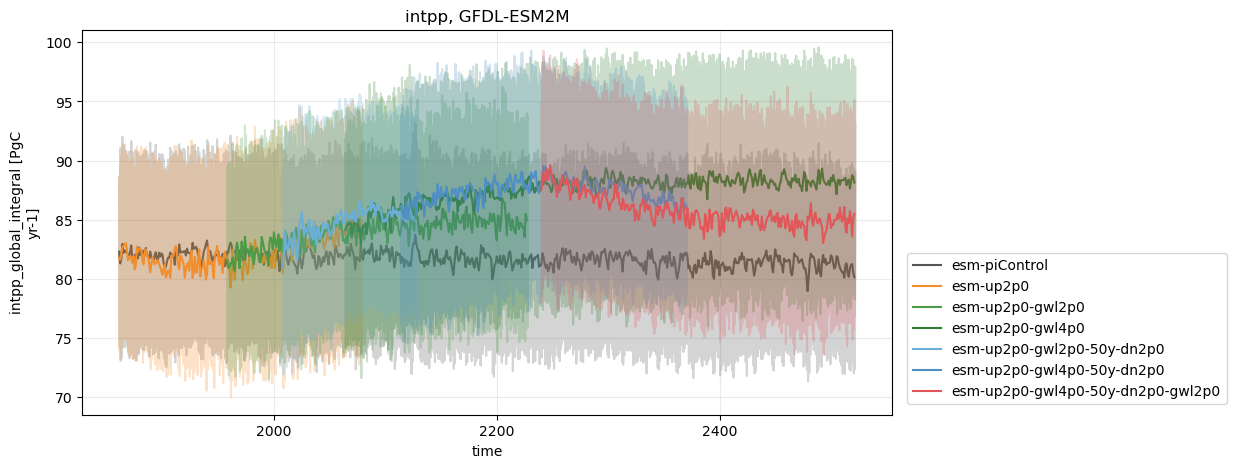

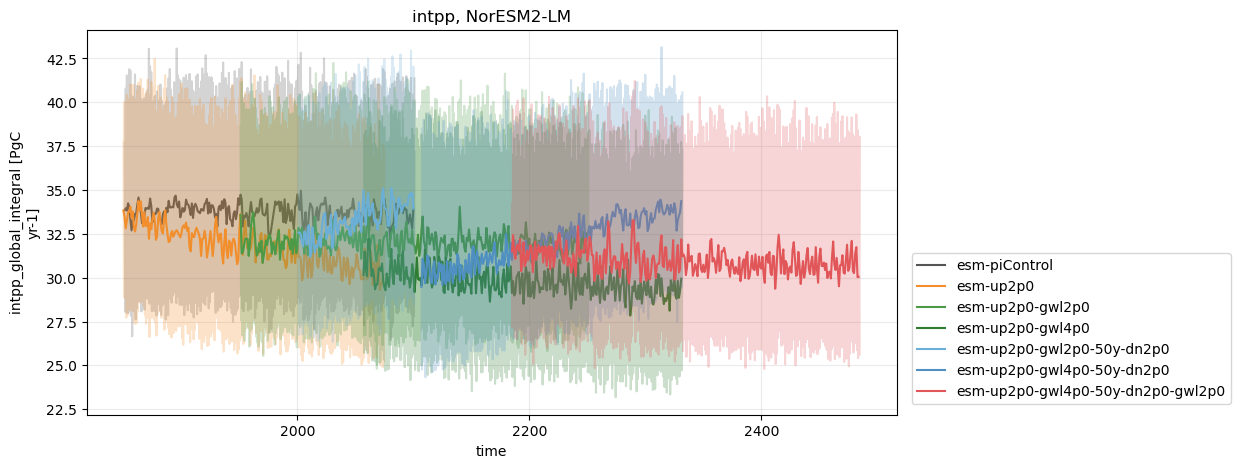

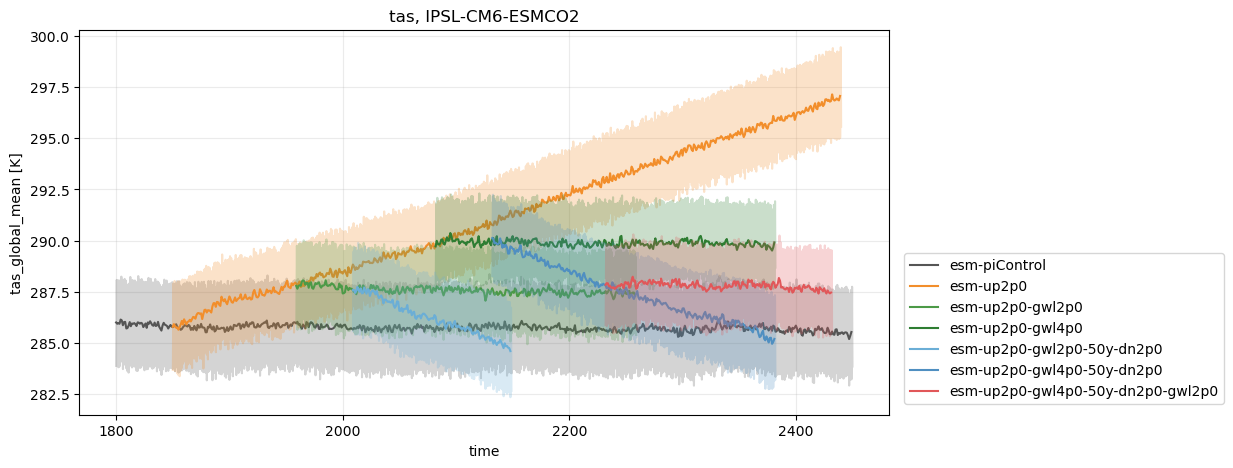

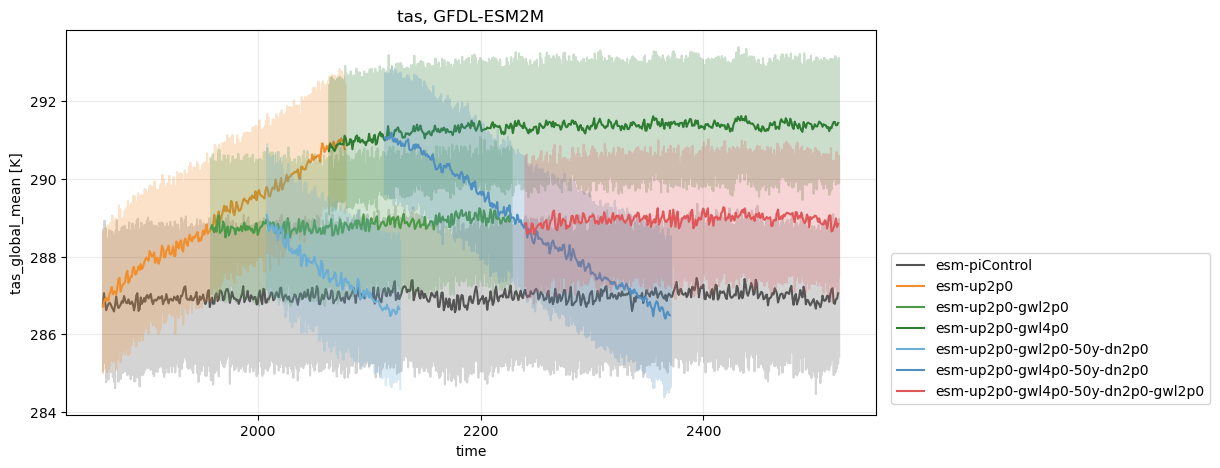

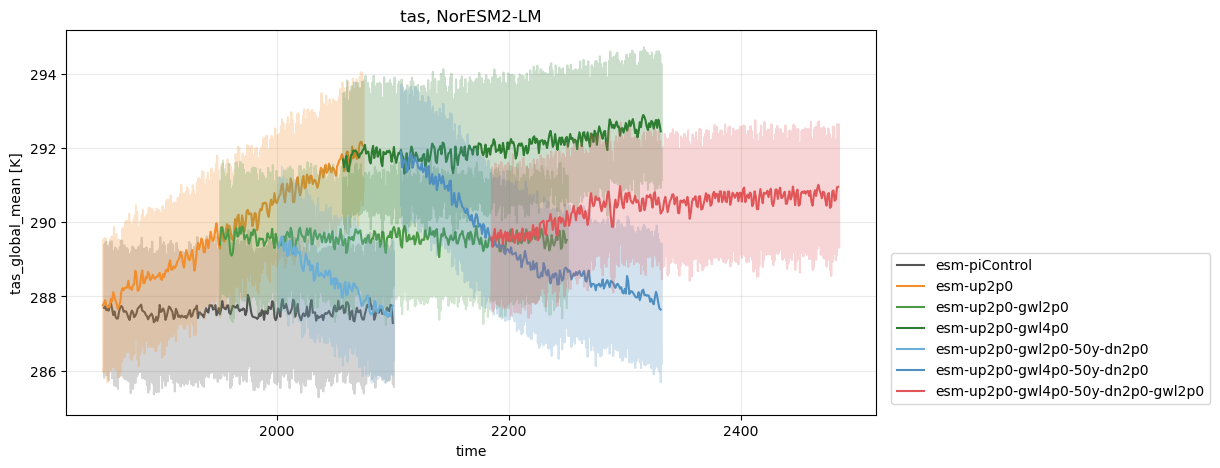

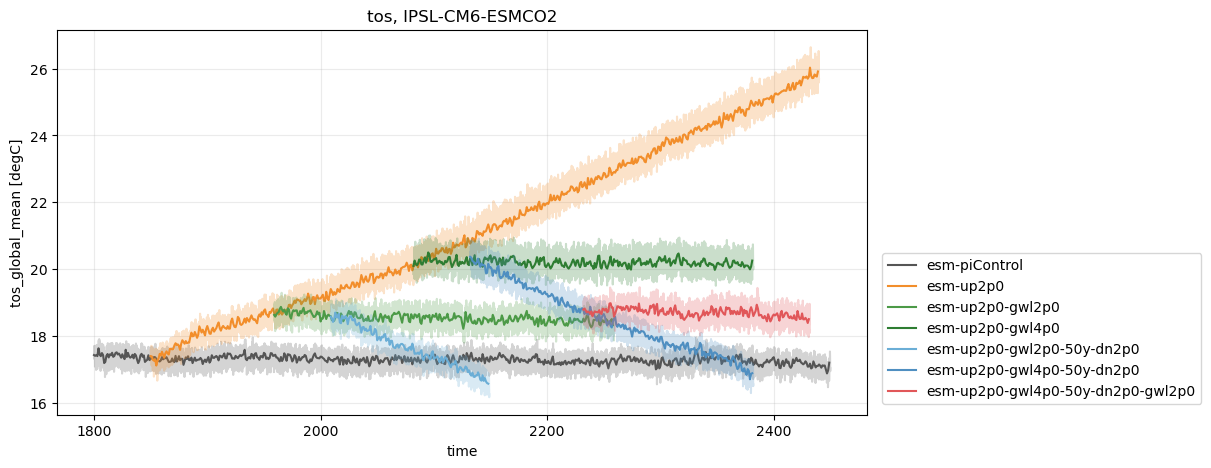

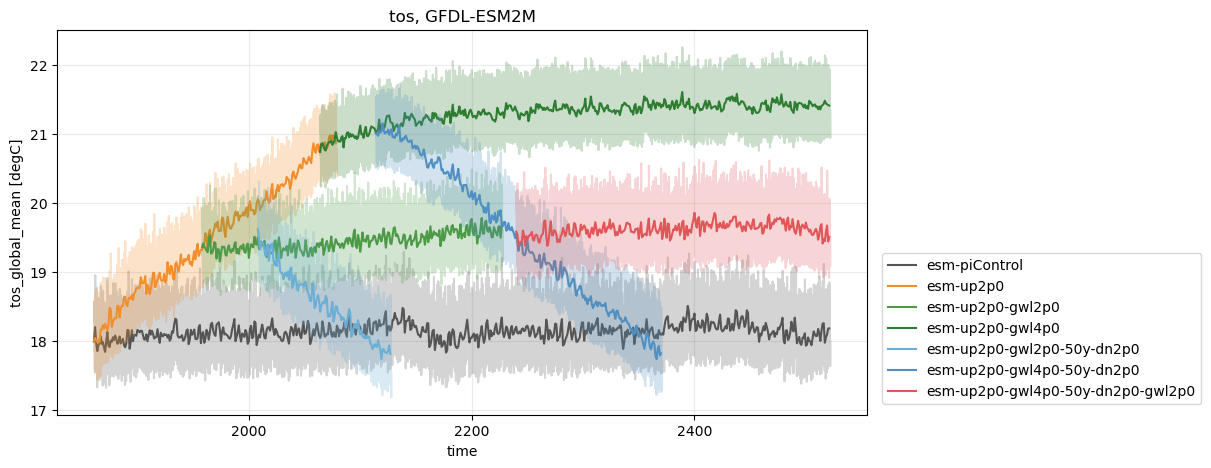

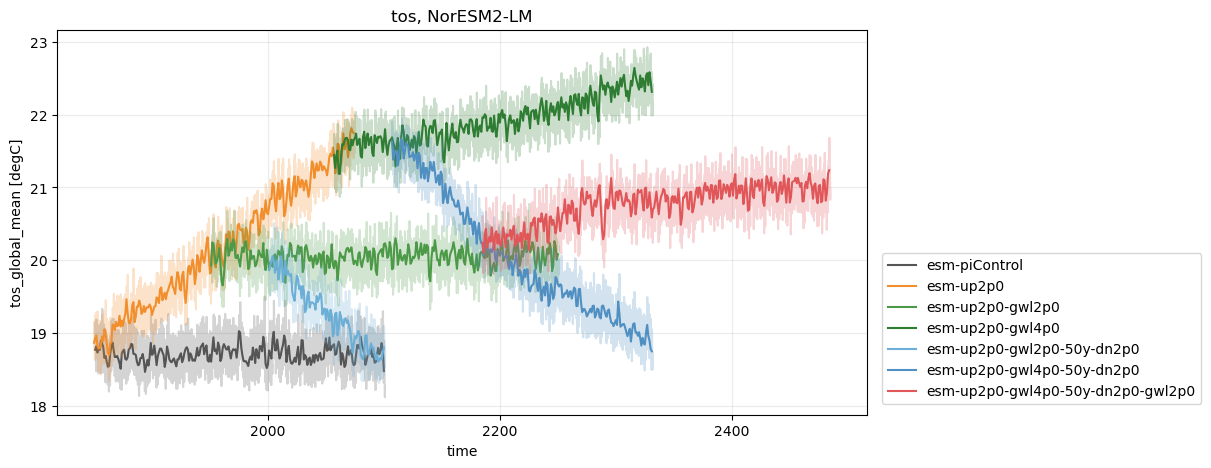

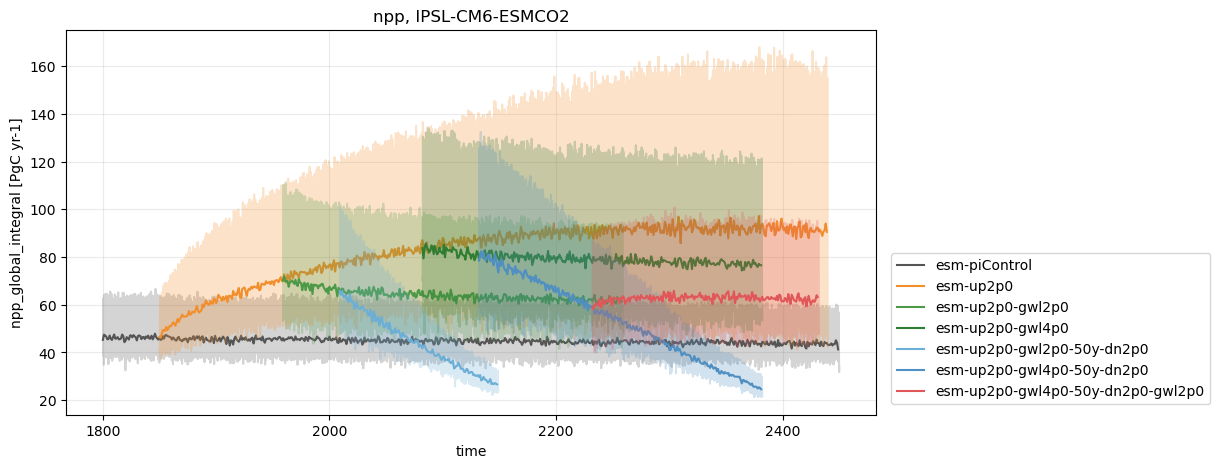

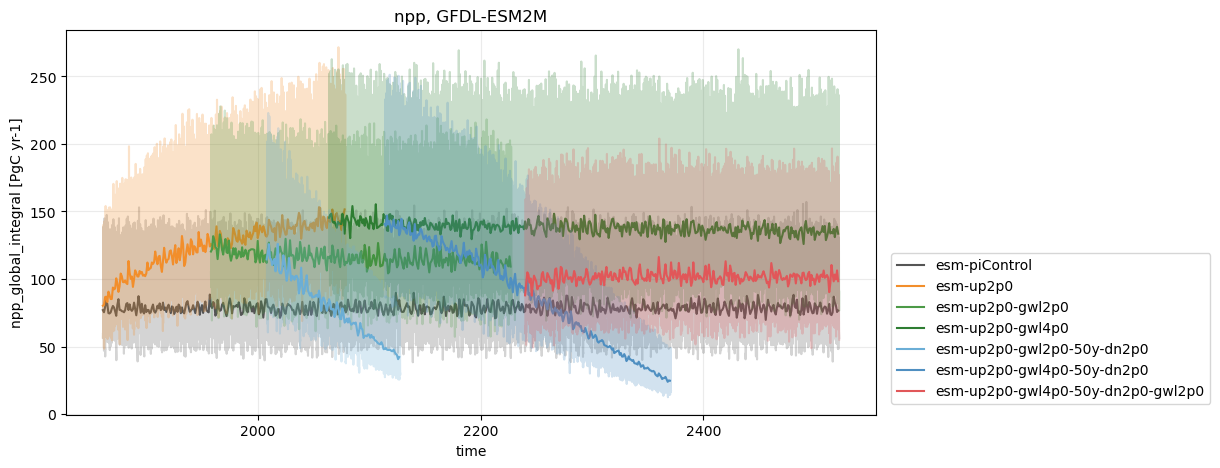

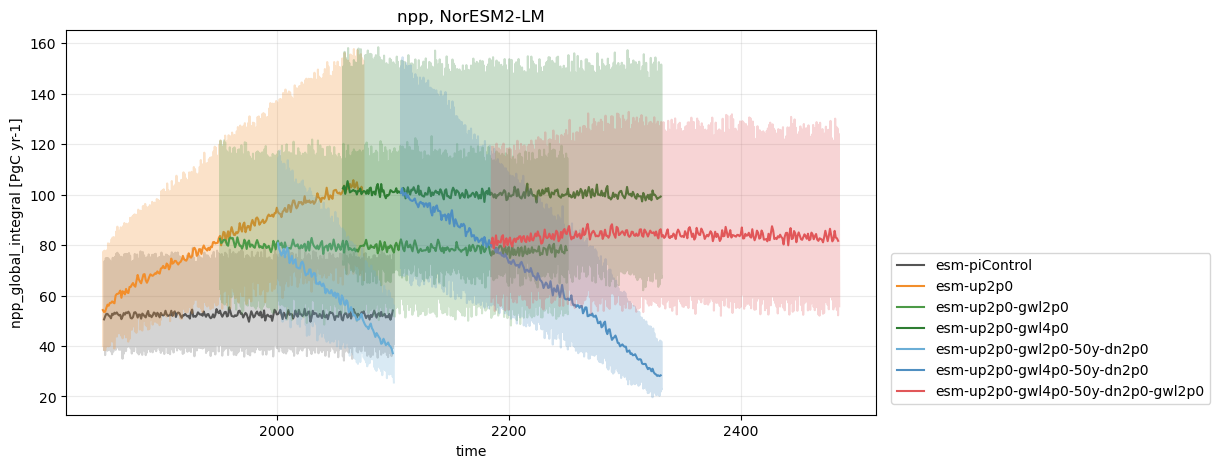

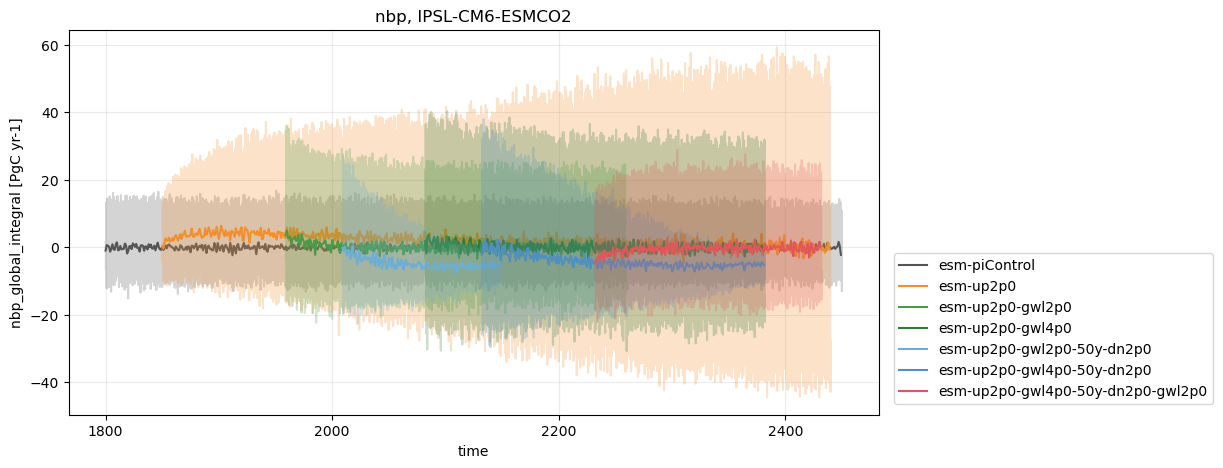

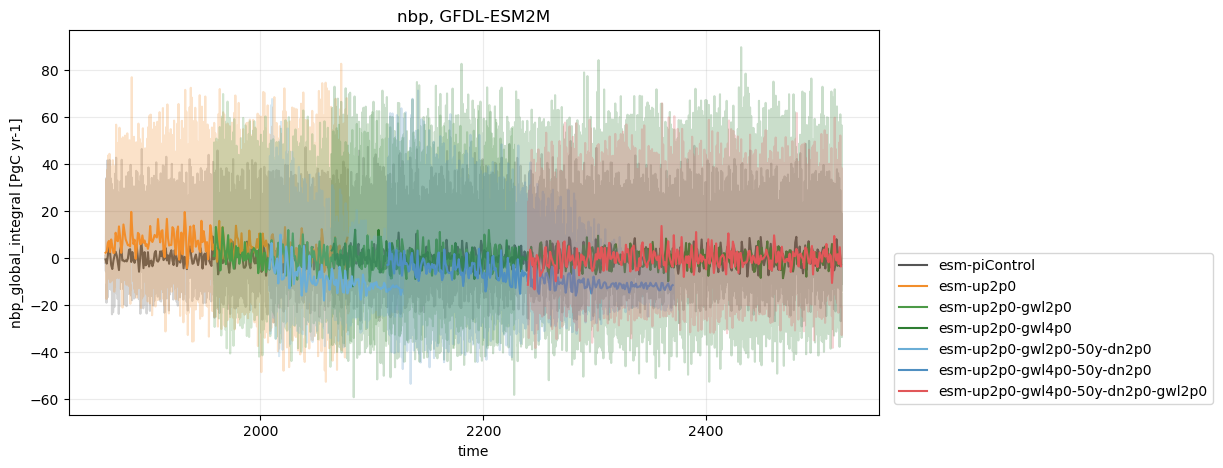

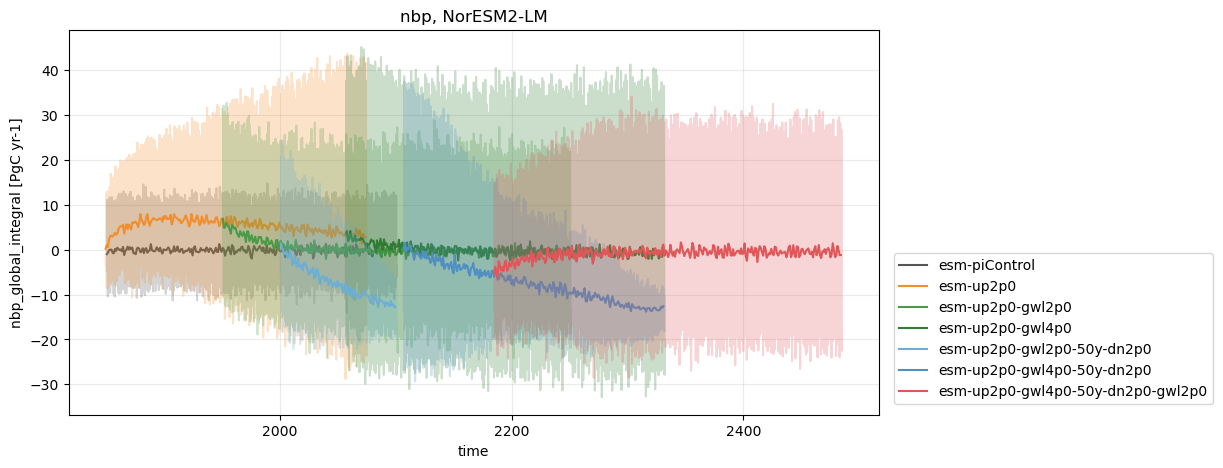

In [4]:
for varia in varias:
    for model in models:
        stat = get_stat(varia)
        mgrab = MODELgrabber.get_grabber(model)
        member = mgrab.get_member()
        #color = model_dict[model].color_id
        global_stats = dict()
        fig, ax = plt.subplots(figsize=(12,5))
        for run in runs:
            try:
                color = run_dict[run].color_id
                load_dir = f'./../01_postprocessed_data/global_time_series/{varia}/{model}/{run}/{member}/{freq_input}/global_{stat}'
                load_string = f'{load_dir}/{varia}_{model}_{run}_{member}_global_{stat}.nc'
                global_stat = xr.open_dataset(load_string,use_cftime=True)
                global_stat = global_stat[f"{varia}_global_{stat}"]
                
                # convert
                global_stat = convert_units(varia,stat,global_stat)
    
                # put into dictionary
                global_stats[run] = global_stat
                #for key in global_stats.keys():
                #print(f'... plotting {run} ...')
                global_stats[run].plot(alpha=0.25,color=color)
                global_stats[run].resample(time="1YS").mean().plot(alpha=1,color=color,label=run)
            except:
                print(f'Nothing to plot for {varia}, {model}, {member}, {run}, {freq_input}, global {stat}.')
        ax.set_title(f'{varia}, {model}')
        ax.grid(alpha=0.25)
        plt.subplots_adjust(right=0.8)
        plt.legend(loc='lower left',bbox_to_anchor=(1.01,0.01))
        plt.show()